# Notebook 1 — EDA: Player Feature Exploration

**Purpose:** Understand the shape, quality, and distributions of `player_features_last10` before modelling.  
Cheater vs. non-cheater distributions are examined across key behavioural signals.  
All figures are saved to `reports/figures/`.

**Data source:** PostgreSQL `raw.player_features_last10`

## Cell 1 — Imports & DB Connection

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from dotenv import load_dotenv
from sqlalchemy import create_engine, text

load_dotenv()

sns.set_theme(style="whitegrid", palette="muted")
FIGURES_DIR = Path("../reports/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

engine = create_engine(os.environ["DATABASE_URL"])
print("Connected to PostgreSQL")

Connected to PostgreSQL


## Cell 2 — Load Data & Basic Stats

In [2]:
with engine.connect() as conn:
    df = pd.read_sql(text("SELECT * FROM raw.player_features_last10"), conn)

print(f"Shape: {df.shape}")
print(f"\nDtypes:\n{df.dtypes}")
print(f"\nNull counts:\n{df.isnull().sum()}")

Shape: (800, 12)

Dtypes:
player_id                   object
matches_played               int64
avg_kills                  float64
avg_deaths                 float64
kd_ratio                   float64
avg_accuracy               float64
stddev_accuracy            float64
avg_headshot_rate          float64
avg_reaction_time_ms       float64
stddev_reaction_time_ms    float64
avg_damage_dealt           float64
cheater_flag                 int64
dtype: object

Null counts:
player_id                  0
matches_played             0
avg_kills                  0
avg_deaths                 0
kd_ratio                   0
avg_accuracy               0
stddev_accuracy            0
avg_headshot_rate          0
avg_reaction_time_ms       0
stddev_reaction_time_ms    0
avg_damage_dealt           0
cheater_flag               0
dtype: int64


In [3]:
# Class balance
balance = df["cheater_flag"].value_counts().rename({0: "Legit", 1: "Cheater"})
pct = df["cheater_flag"].value_counts(normalize=True).mul(100).rename({0: "Legit", 1: "Cheater"})
print(pd.concat([balance, pct.round(1)], axis=1, keys=["count", "pct%"]))

              count  pct%
cheater_flag             
Legit           760  95.0
Cheater          40   5.0


In [4]:
print(df.describe().T.round(4))

                         count       mean       std       min        25%  \
matches_played           800.0     9.5525    1.1298    3.0000    10.0000   
avg_kills                800.0     8.4055    3.4805    2.7500     6.7000   
avg_deaths               800.0     6.3483    1.4992    1.2000     5.6000   
kd_ratio                 800.0     1.6410    1.9851    0.3056     0.9880   
avg_accuracy             800.0     0.3216    0.0968    0.1905     0.2800   
stddev_accuracy          800.0     0.0963    0.0243    0.0393     0.0796   
avg_headshot_rate        800.0     0.2219    0.1016    0.1179     0.1817   
avg_reaction_time_ms     800.0   213.2291   34.8326   61.8900   207.1750   
stddev_reaction_time_ms  800.0    47.4754   13.2469   10.1405    39.0932   
avg_damage_dealt         800.0  1318.8100  525.5372  683.9000  1101.0750   
cheater_flag             800.0     0.0500    0.2181    0.0000     0.0000   

                               50%        75%        max  
matches_played             1

## Cell 3 — Distributions Split by Cheater Flag

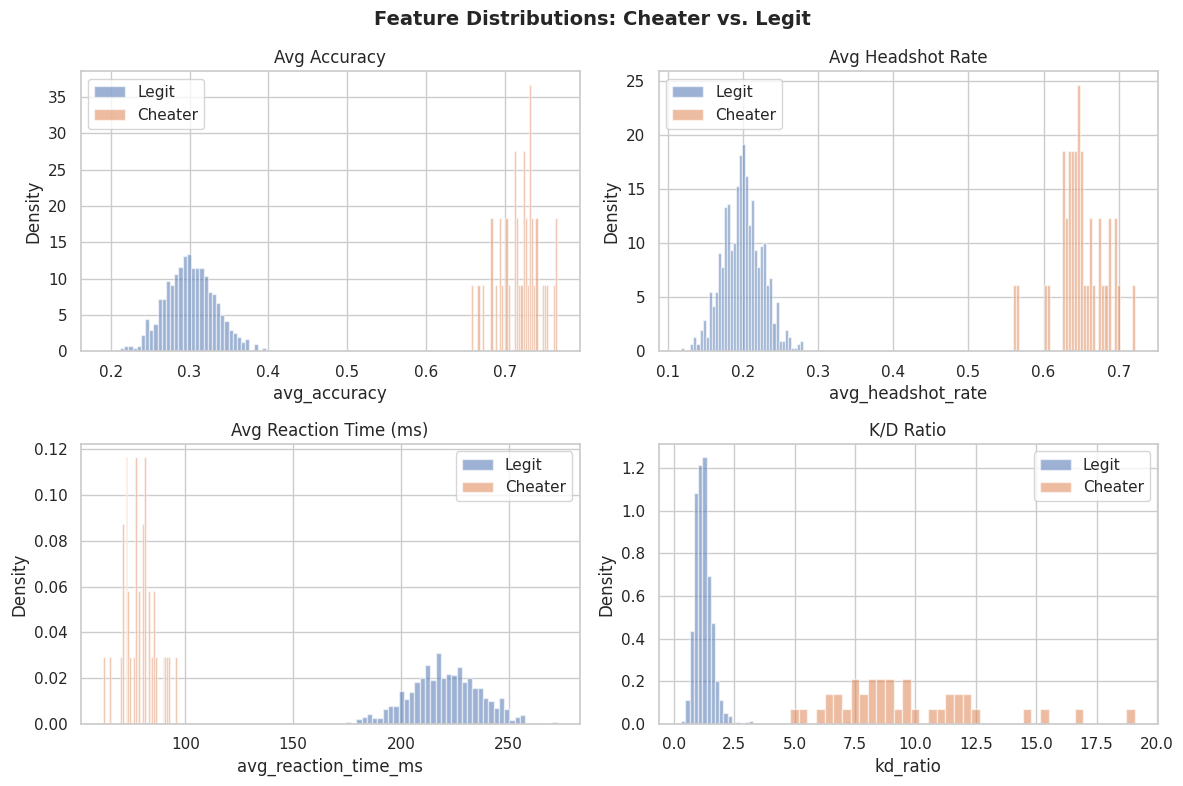

Saved 01_distributions.png


In [5]:
FEATURES = [
    ("avg_accuracy",          "Avg Accuracy"),
    ("avg_headshot_rate",     "Avg Headshot Rate"),
    ("avg_reaction_time_ms",  "Avg Reaction Time (ms)"),
    ("kd_ratio",              "K/D Ratio"),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Feature Distributions: Cheater vs. Legit", fontsize=14, fontweight="bold")

labels = {0: "Legit", 1: "Cheater"}
colors = {0: "#4C72B0", 1: "#DD8452"}

for ax, (col, title) in zip(axes.flat, FEATURES):
    for flag in [0, 1]:
        subset = df.loc[df["cheater_flag"] == flag, col]
        subset.plot.hist(
            ax=ax, bins=40, alpha=0.55,
            color=colors[flag], label=labels[flag],
            density=True
        )
    ax.set_title(title)
    ax.set_xlabel(col)
    ax.set_ylabel("Density")
    ax.legend()

plt.tight_layout()
fig.savefig(FIGURES_DIR / "01_distributions.png", dpi=150)
plt.show()
print("Saved 01_distributions.png")

## Cell 4 — Boxplots by Cheater Flag

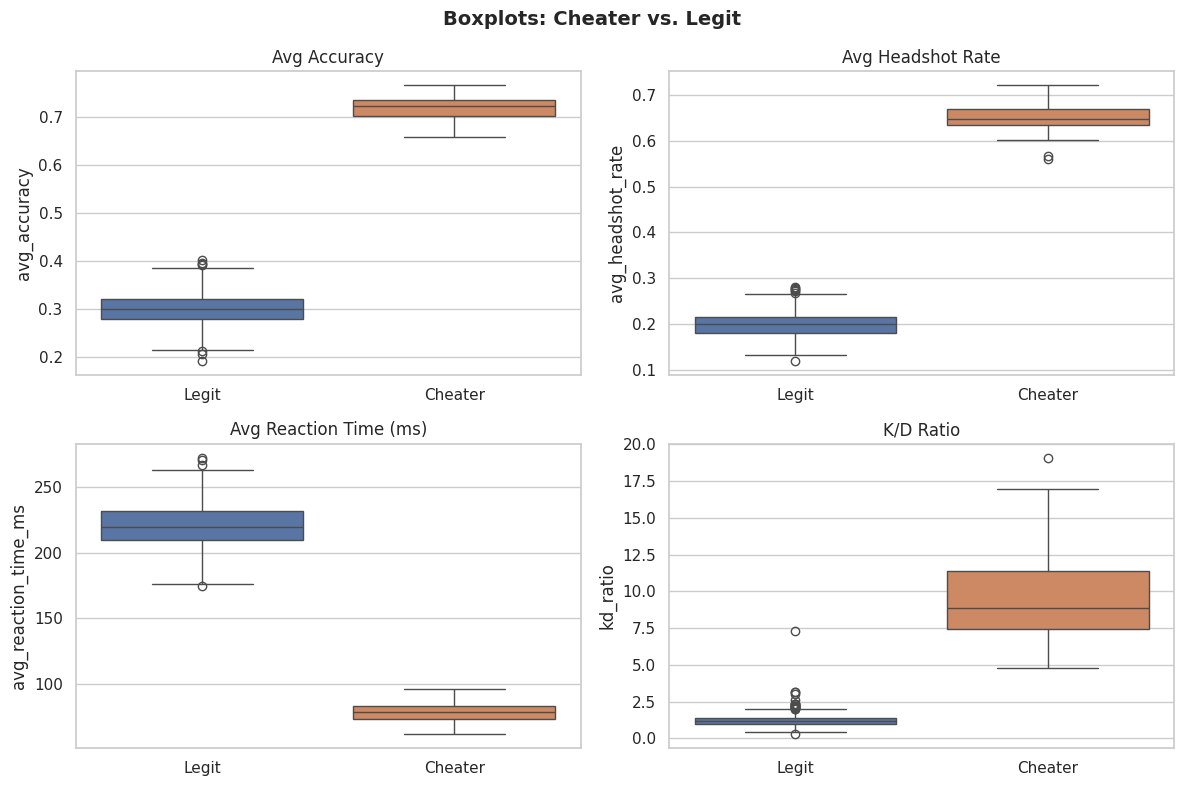

Saved 02_boxplots.png


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Boxplots: Cheater vs. Legit", fontsize=14, fontweight="bold")

df_plot = df.copy()
df_plot["label"] = df_plot["cheater_flag"].map({0: "Legit", 1: "Cheater"})

for ax, (col, title) in zip(axes.flat, FEATURES):
    sns.boxplot(
        data=df_plot, x="label", y=col, ax=ax,
        hue="label", palette={"Legit": "#4C72B0", "Cheater": "#DD8452"},
        order=["Legit", "Cheater"], legend=False
    )
    ax.set_title(title)
    ax.set_xlabel("")

plt.tight_layout()
fig.savefig(FIGURES_DIR / "02_boxplots.png", dpi=150)
plt.show()
print("Saved 02_boxplots.png")

## Cell 5 — Correlation Heatmap

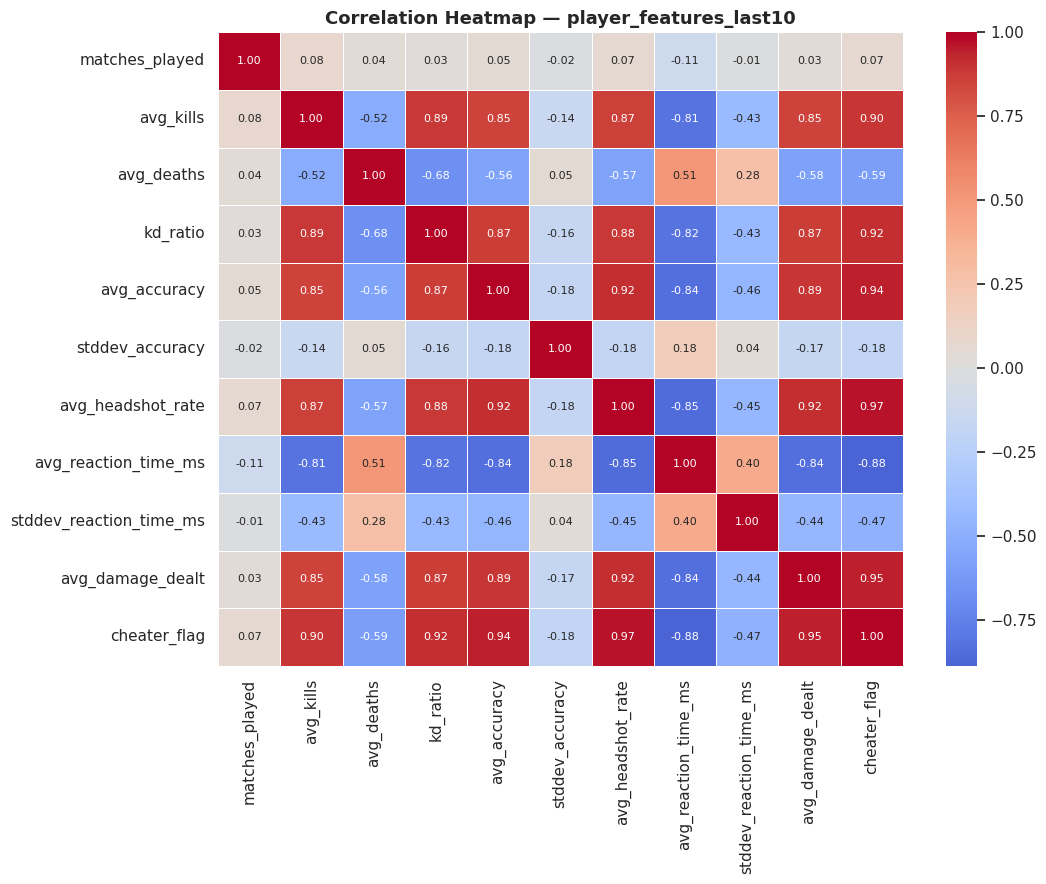

Saved 03_correlation_heatmap.png


In [7]:
numeric_cols = [
    "matches_played", "avg_kills", "avg_deaths", "kd_ratio",
    "avg_accuracy", "stddev_accuracy", "avg_headshot_rate",
    "avg_reaction_time_ms", "stddev_reaction_time_ms",
    "avg_damage_dealt", "cheater_flag"
]

corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    corr, annot=True, fmt=".2f", cmap="coolwarm",
    center=0, linewidths=0.5, ax=ax,
    annot_kws={"size": 8}
)
ax.set_title("Correlation Heatmap — player_features_last10", fontsize=13, fontweight="bold")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "03_correlation_heatmap.png", dpi=150)
plt.show()
print("Saved 03_correlation_heatmap.png")

## Cell 6 — Top 10 Most Suspicious Players

In [8]:
top10 = (
    df
    .sort_values(["avg_accuracy", "avg_reaction_time_ms"], ascending=[False, True])
    .head(10)[
        ["player_id", "avg_accuracy", "avg_headshot_rate",
         "avg_reaction_time_ms", "kd_ratio", "matches_played", "cheater_flag"]
    ]
    .reset_index(drop=True)
)
top10.index += 1
print("Top 10 Most Suspicious Players (by avg_accuracy DESC, reaction_time ASC)")
print(top10.to_string())

Top 10 Most Suspicious Players (by avg_accuracy DESC, reaction_time ASC)
      player_id  avg_accuracy  avg_headshot_rate  avg_reaction_time_ms  kd_ratio  matches_played  cheater_flag
1   player_0095        0.7663             0.6933                 81.08    5.3158              10             1
2   player_0089        0.7663             0.6996                 82.70    8.0800              10             1
3   player_0142        0.7632             0.6437                 78.70    8.6154              10             1
4   player_0228        0.7541             0.6626                 86.58    8.8261               9             1
5   player_0006        0.7526             0.6354                 90.38    9.5357              10             1
6   player_0250        0.7478             0.6306                 92.00    6.0323              10             1
7   player_0104        0.7417             0.6479                 72.93   16.9286              10             1
8   player_0032        0.7396          